<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 141.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 145.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 143.3 MB/s eta 0:00:00


##### Import Necessary Modules:


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [3]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [4]:
## Write your code here
# 1. Display basic information about the dataset (columns, data types, null counts)
print("--- Dataset Info ---")
df.info()

# 2. Display summary statistics for numerical columns
print("\n--- Summary Statistics ---")
print(df.describe())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 56.9 MB

--- Summary Statistics ---
         ResponseId      CompTotal       WorkExp  JobSatPoints_1  \
count  65447.000000   3.374000e+04  29659.000000    29325.000000   
mean   32714.001528  2.963841e+145     11.467143       18.580460   
std    18893.063225  5.444117e+147      9.168610       25.966005   
min        1.000000   0.000000e+00      0.000000        0.000000   
25%    16352.500000   6.000000e+04      4.000000        0.000000   
50%    32714.000000   1.100000e+05      9.000000       10.000000   
75%    49075.500000   2.500000e+05     16.000000       22.000000   
max    65437.000000  1.000000e+150     50.000000      100.000000   

       JobSatPoints_4  JobSatPoints_5  JobSatPoints_6  JobSatPoints_7  \
count    29394.000000    29412.000000    29451.000000    29449.000000   
mean         7.521884 

### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [5]:
## Write your code here
# Identify and sum the missing values for each column
missing_values_count = df.isnull().sum()

# Display columns that have at least one missing value
print("Columns with missing values:")
print(missing_values_count[missing_values_count > 0])

Columns with missing values:
RemoteWork             10635
CodingActivities       10975
EdLevel                 4653
LearnCode               4949
LearnCodeOnline        16202
                       ...  
JobSatPoints_11        36001
SurveyLength            9257
SurveyEase              9201
ConvertedCompYearly    42012
JobSat                 36321
Length: 109, dtype: int64


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



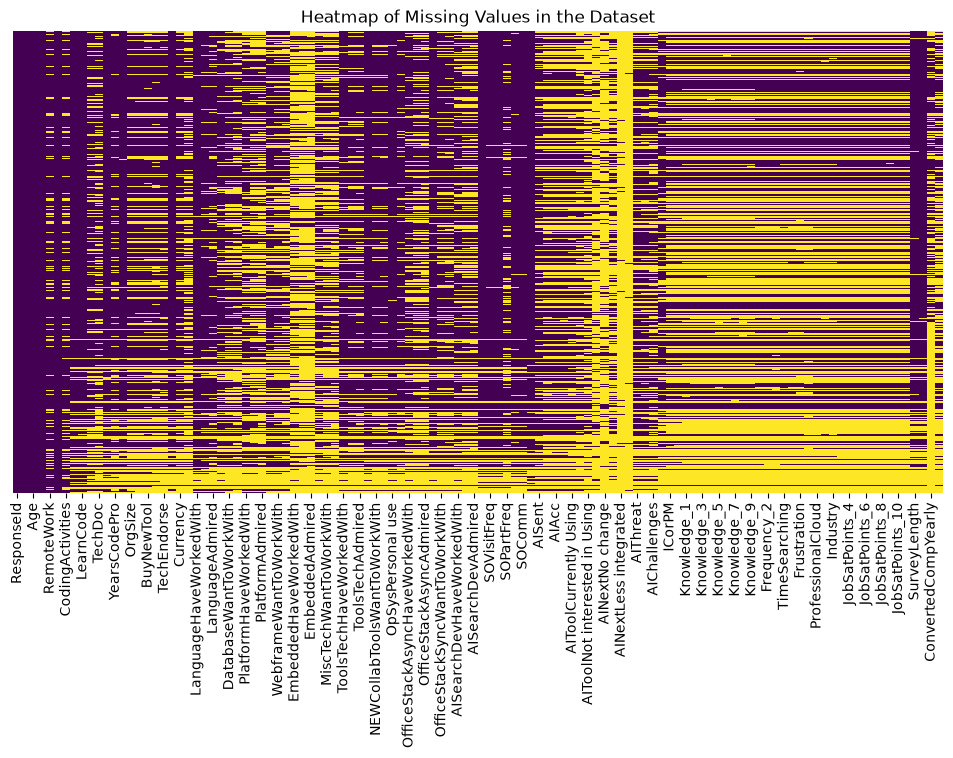

In [6]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

# Set the figure size for the heatmap
plt.figure(figsize=(12, 6))

# Create a heatmap showing where missing values (True) exist
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')

# Add a title and show the plot
plt.title("Heatmap of Missing Values in the Dataset")
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [8]:
## Write your code here
# Count the number of missing values specifically in the 'Employment' column
missing_employment = df['Employment'].isnull().sum()

print(f"Number of missing rows in the 'Employment' column: {missing_employment}")

Number of missing rows in the 'Employment' column: 0


### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [9]:
## Write your code here
# Identify the most frequent value in the 'Employment' column
most_frequent_employment = df['Employment'].mode()[0]

print(f"The most frequent value in the 'Employment' column is: {most_frequent_employment}")

The most frequent value in the 'Employment' column is: Employed, full-time


##### Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [10]:
## Write your code here
# Impute missing values in the 'Employment' column using the most frequent value
df['Employment'] = df['Employment'].fillna(most_frequent_employment)

# Verify that there are no more missing values in the column
print(f"Missing values in 'Employment' after imputation: {df['Employment'].isnull().sum()}")

Missing values in 'Employment' after imputation: 0


### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


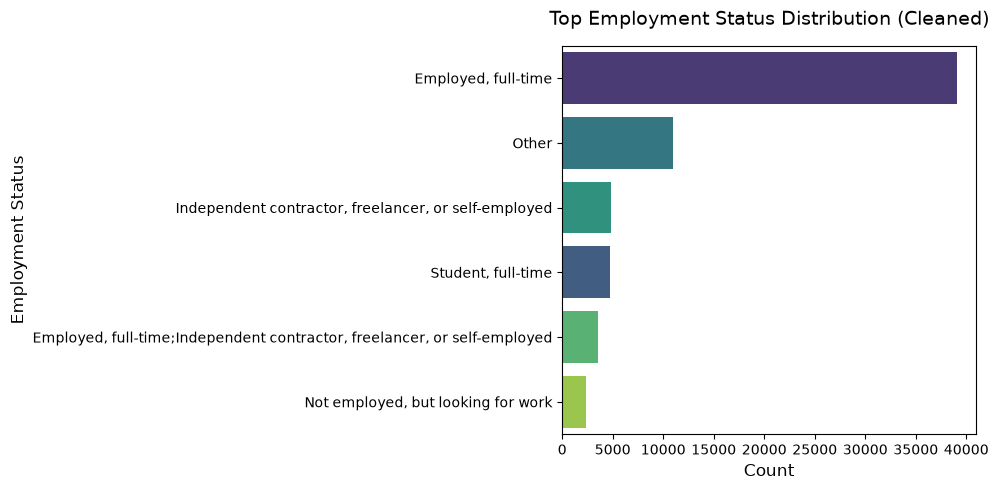

In [18]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress minor layout warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 1. Get the top 5 most frequent employment statuses
top_categories = df['Employment'].value_counts().nlargest(5).index

# 2. Create a temporary column where anything outside the top 5 is labeled 'Other'
df_plot = df.copy()
df_plot['Employment_Grouped'] = df_plot['Employment'].apply(lambda x: x if x in top_categories else 'Other')

# 3. Set up a clean, compact figure size
plt.figure(figsize=(10, 5))

# 4. Plot only the grouped categories
sns.countplot(
    data=df_plot, 
    y='Employment_Grouped', 
    order=df_plot['Employment_Grouped'].value_counts().index, 
    hue='Employment_Grouped', 
    legend=False, 
    palette='viridis'
)

# Add clear titles and labels
plt.title("Top Employment Status Distribution (Cleaned)", fontsize=14, pad=15)
plt.xlabel("Count", fontsize=12)
plt.ylabel("Employment Status", fontsize=12)

# Adjust margins perfectly
plt.tight_layout()
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
